In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model

np.random.seed(123)
tf.random.set_seed(123)

In [22]:
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.preprocessing import StandardScaler

In [23]:
import os
os.chdir(r'G:\My Drive\Study\Time Series Analysis Udemy\Data\time series analysis forecasting')
os.getcwd()

'G:\\My Drive\\Study\\Time Series Analysis Udemy\\Data\\time series analysis forecasting'

In [24]:
df0 = pd.read_csv('sp500sub.csv', index_col= 'Date', parse_dates = True)

In [25]:
df0.head()

,Open,High,Low,Close,Adj Close,Volume,Name
Date,,,,,,,
2010-01-04,9.22,9.51,9.17,9.50,9.50,1865400.0,INCY
2010-01-05,9.51,10.29,9.45,10.27,10.27,7608900.0,INCY
2010-01-06,10.38,11.09,10.35,11.00,11.00,8046700.0,INCY
2010-01-07,11.00,11.06,10.62,10.82,10.82,3680300.0,INCY
2010-01-08,10.82,11.00,10.75,10.94,10.94,1529300.0,INCY


In [26]:
df = df0[df0['Name']=='SBUX'][['Close']].copy()

In [27]:
df.head()

,Close
Date,
2010-01-04,11.525
2010-01-05,11.795
2010-01-06,11.710
2010-01-07,11.680
2010-01-08,11.640


In [28]:
df['LogClose'] = np.log(df['Close'])

In [29]:
df['DiffLogClose'] = df['LogClose'].diff()

In [30]:
Ntest=21
train = df[:-Ntest]
test = df[-Ntest:]

<Axes: xlabel='Date'>

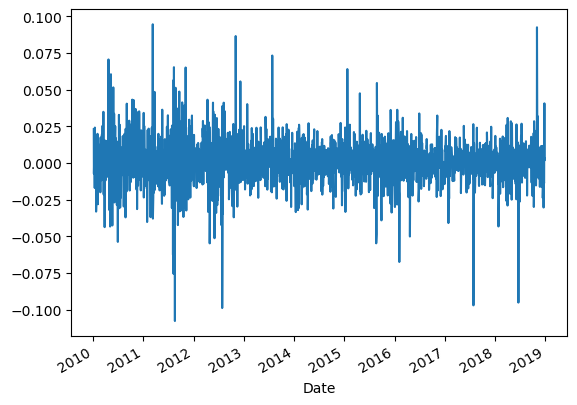

In [31]:
df['DiffLogClose'].plot()

In [32]:
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train[['DiffLogClose']]) 
test_scaled = scaler.transform(test[['DiffLogClose']])

In [33]:
''' in DNN, it is always better to standardize or normalize'''

' in DNN, it is always better to standardize or normalize'

In [34]:
train_idx = df.index <= train.index[-1]
test_idx = ~train_idx

In [35]:
df.loc[train_idx,'ScaledLogReturn'] = train_scaled.flatten()
df.loc[test_idx,'ScaledLogReturn'] = test_scaled.flatten()

In [36]:
series = df['ScaledLogReturn'].dropna().to_numpy()

T = 10
X = []
Y = []

for t in range(len(series)-T):
    x = series[t:t+T]
    y = series[t+T]
    X.append(x)
    Y.append(y)

X = np.array(X).reshape(-1,T)
Y = np.array(Y)
N = len(X)
print("X.shape:", X.shape,"Y.shape:", Y.shape)

X.shape: (2252, 10) Y.shape: (2252,)


In [37]:
''' as mentioned in the previous notebooks as well, this method is not correct due to data leakage happenning in test set.
.the label of the 1st row of test set is present as the last feature in the new row of the test set'''

' as mentioned in the previous notebooks as well, this method is not correct due to data leakage happenning in test set.\n.the label of the 1st row of test set is present as the last feature in the new row of the test set'

In [38]:
Xtrain, Ytrain = X[:-Ntest], Y[:-Ntest]
Xtest, Ytest = X[-Ntest:], Y[-Ntest:] 

In [39]:
''' the label of the 1st row of test set is present as the last feature in the new row of the test set.
this could lead to much better performance in the test set giving false impression that model performs very well in the test set'''

' the label of the 1st row of test set is present as the last feature in the new row of the test set.\nthis could lead to much better performance in the test set giving false impression that model performs very well in the test set'

In [40]:
# Basic ANN
i = Input(shape = (T,))
x = Dense(32, activation ='relu')(i)
x = Dense(1)(x) # keras defaults to linear activation function meaning no activation
model = Model(i,x)

model.compile(loss = 'mse', optimizer = 'adam')

In [41]:
r = model.fit(
    Xtrain,
    Ytrain,
    epochs = 200,
    validation_data = (Xtest, Ytest)
)

Epoch 1/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 1.3766 - val_loss: 1.4321
Epoch 2/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0964 - val_loss: 1.3284
Epoch 3/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0600 - val_loss: 1.2600
Epoch 4/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0394 - val_loss: 1.2163
Epoch 5/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0242 - val_loss: 1.1849
Epoch 6/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0117 - val_loss: 1.1590
Epoch 7/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0011 - val_loss: 1.1392
Epoch 8/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9926 - val_loss: 1.1225
Epoch 9/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9854 - val_loss: 1.1091
Epoch 10/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9792 - val_loss: 1.0979
Epoch 11/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9738 - val_loss: 1.0897
Epoch 12/200
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9

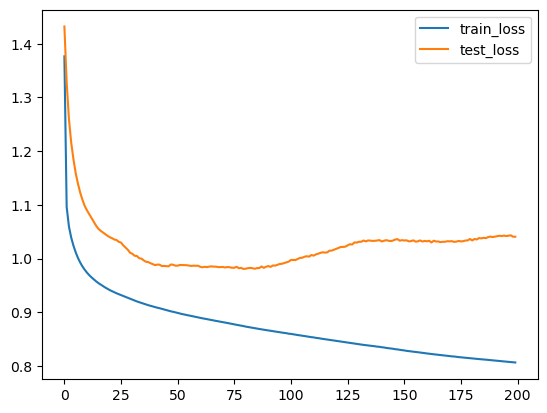

In [42]:
plt.plot(r.history['loss'], label = 'train_loss')
plt.plot(r.history['val_loss'], label = 'test_loss')
plt.legend()

In [43]:
'''overfitting as observed by the above '''

'overfitting as observed by the above '

In [44]:
train_idx[:T+1] = False # since first T+1 values non predictable

In [45]:
Ptrain = model.predict(Xtrain)
Ptest = model.predict(Xtest)

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step


In [46]:
Ptrain = scaler.inverse_transform(Ptrain).flatten()
Ptest = scaler.inverse_transform(Ptest).flatten()

In [47]:
df.loc[train_idx, 'Diff ANN Train Prediction'] = Ptrain
df.loc[test_idx, 'Diff ANN Test Prediction'] = Ptest

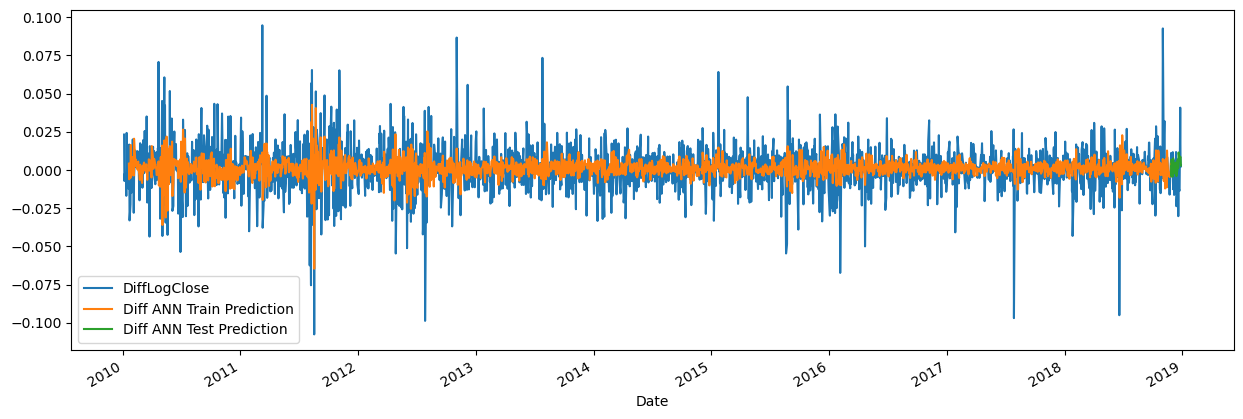

In [48]:
cols = ['DiffLogClose','Diff ANN Train Prediction','Diff ANN Test Prediction'] 
df[cols].plot(figsize=(15,5));

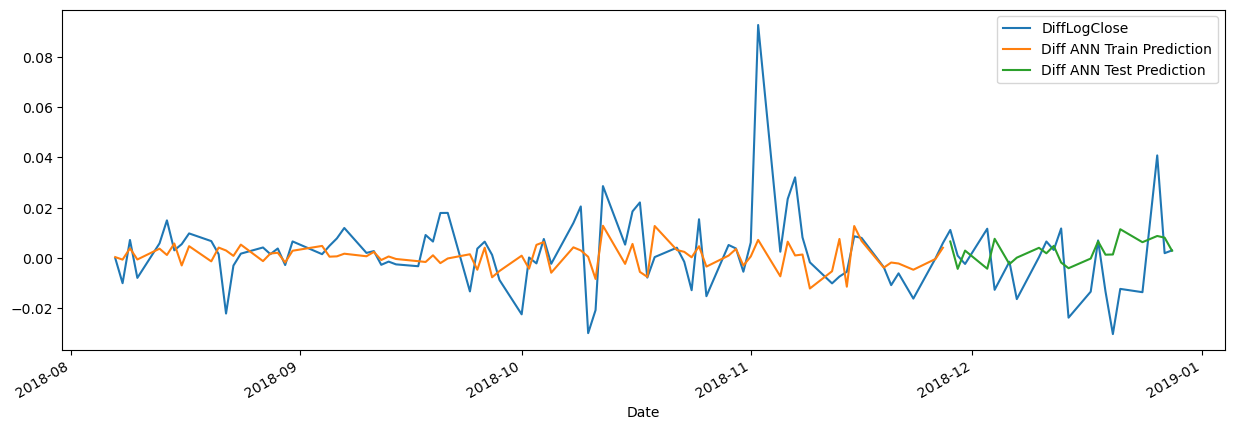

In [49]:
cols = ['DiffLogClose','Diff ANN Train Prediction','Diff ANN Test Prediction'] 
df.iloc[-100:][cols].plot(figsize=(15,5));

In [50]:
df['ShiftLogClose'] = df['LogClose'].shift(1)
prev = df['ShiftLogClose']

In [51]:
last_train = train.iloc[-1]['LogClose']

In [52]:
df.loc[train_idx, '1step_train'] = prev[train_idx] + Ptrain
df.loc[test_idx, '1step_test'] = prev[test_idx] + Ptest

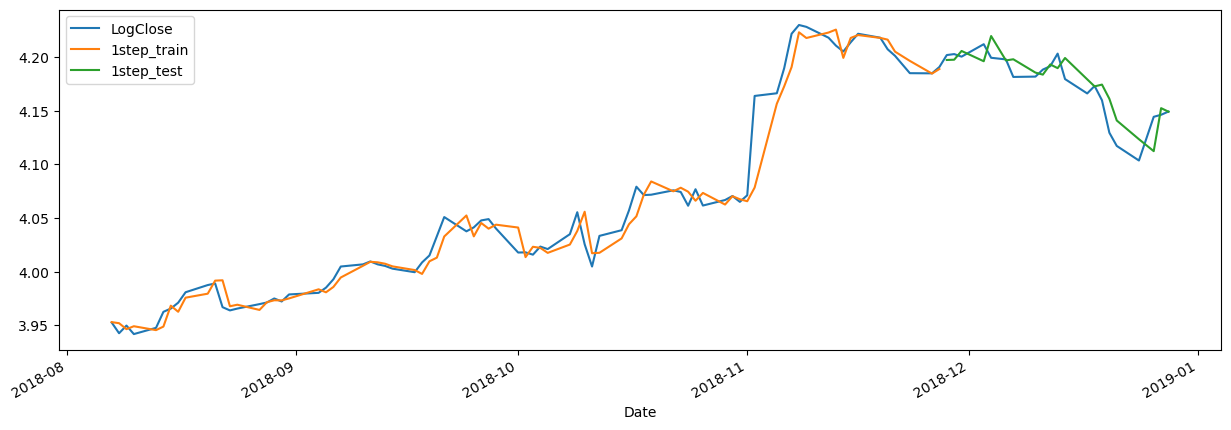

In [53]:
df.iloc[-100:][['LogClose','1step_train','1step_test']].plot(figsize =(15,5));

In [54]:
'''looks like lagging the previous value, naive forecast'''

'looks like lagging the previous value, naive forecast'

In [55]:
#multistep forecast
multistep_predictions = []
last_x = Xtest[0]

while len(multistep_predictions) < Ntest:
    p = model.predict(last_x.reshape(1,-1))[0]
    multistep_predictions.append(p)

    last_x = np.roll(last_x, -1)
    last_x[-1] = p

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


C:\Users\VARUN\AppData\Local\Temp\ipykernel_1912\44270791.py:10: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  last_x[-1] = p


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step


In [56]:
type(multistep_predictions)

list

In [57]:
multistep_predictions

[array([0.3796664], dtype=float32),
 array([-0.35340214], dtype=float32),
 array([0.15037061], dtype=float32),
 array([-0.25866312], dtype=float32),
 array([0.20410652], dtype=float32),
 array([-0.04659222], dtype=float32),
 array([0.19599847], dtype=float32),
 array([0.12157363], dtype=float32),
 array([-0.10387944], dtype=float32),
 array([-0.24018832], dtype=float32),
 array([0.03961765], dtype=float32),
 array([-0.01758724], dtype=float32),
 array([-0.04260493], dtype=float32),
 array([0.08789553], dtype=float32),
 array([-0.09014947], dtype=float32),
 array([-0.04138789], dtype=float32),
 array([0.05934515], dtype=float32),
 array([-0.16112584], dtype=float32),
 array([-0.14119217], dtype=float32),
 array([-0.01220736], dtype=float32),
 array([-0.2003242], dtype=float32)]

In [58]:
multistep_predictions = np.array(multistep_predictions)
multistep_predictions = scaler.inverse_transform(multistep_predictions.reshape(-1,1)).flatten()

In [59]:
multistep_predictions

array([ 6.5411511e-03, -4.5840177e-03,  3.0613209e-03, -3.1462424e-03,
        3.8768258e-03,  7.2180395e-05,  3.7537767e-03,  2.6242929e-03,
       -7.9721981e-04, -2.8658658e-03,  1.3805155e-03,  5.1236479e-04,
        1.3269209e-04,  2.1131886e-03, -5.8885163e-04,  1.5116208e-04,
        1.6799034e-03, -1.6660006e-03, -1.3634840e-03,  5.9401063e-04,
       -2.2608812e-03], dtype=float32)

In [60]:
df.loc[test_idx, 'multistep'] = last_train + np.cumsum(multistep_predictions)

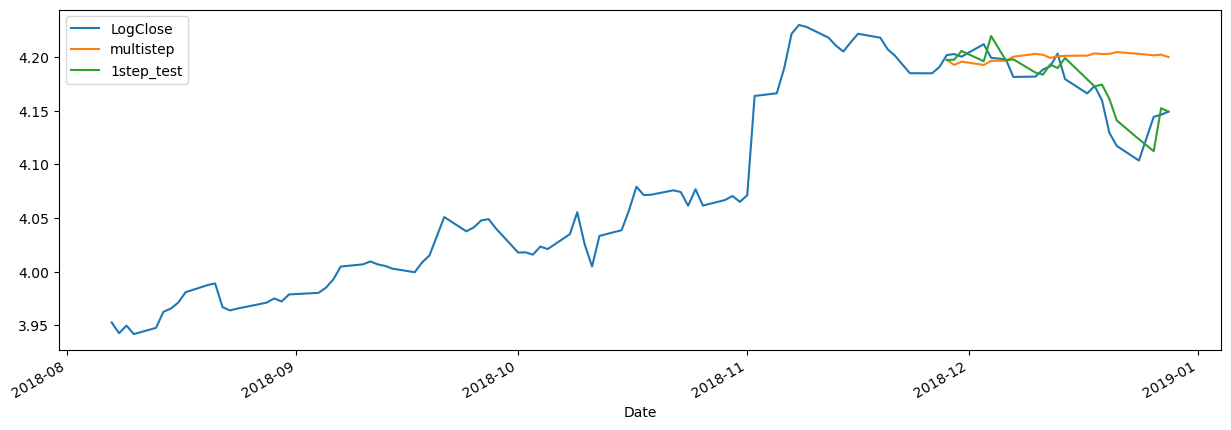

In [61]:
df.iloc[-100:][['LogClose','multistep','1step_test']].plot(figsize =(15,5));

In [62]:
'''straight line with a trend since it is mostly taking into account the last known value'''

'straight line with a trend since it is mostly taking into account the last known value'

In [63]:
# multi output supervised 
Tx = T
Ty = Ntest
X = []
Y = []

for t in range(len(series) - Tx -Ty + 1):
    x = series[t:t+Tx]
    X.append(x)
    y = series[t+Tx:t+Tx+Ty] 
    Y.append(y)

X = np.array(X).reshape(-1, Tx)
Y = np.array(Y).reshape(-1, Ty)
N = len(X)
print("X.shape",X.shape, "Y.shape", Y.shape)

X.shape (2232, 10) Y.shape (2232, 21)


In [64]:
Xtrain_m, Ytrain_m = X[:-1], Y[:-1]
Xtest_m, Ytest_m = X[-1:], Y[-1:]

In [65]:
i = Input(shape = (Tx,))
x = Dense(32, activation = 'relu')(i)
x = Dense(Ty)(x) # now has size Ty"
model = Model(i,x)

In [66]:
model.compile(loss='mse', optimizer='adam')

In [67]:
r = model.fit(
    Xtrain_m,
    Ytrain_m,
    epochs = 100,
    validation_data = (Xtest_m, Ytest_m)
)

Epoch 1/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1.1466 - val_loss: 0.9844
Epoch 2/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0610 - val_loss: 0.9896
Epoch 3/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0343 - val_loss: 0.9950
Epoch 4/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0208 - val_loss: 0.9993
Epoch 5/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0128 - val_loss: 1.0021
Epoch 6/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0075 - val_loss: 1.0041
Epoch 7/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0039 - val_loss: 1.0055
Epoch 8/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0011 - val_loss: 1.0072
Epoch 9/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9990 - val_loss: 1.0074
Epoch 10/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9972 - val_loss: 1.0067
Epoch 11/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9957 - val_loss: 1.0062
Epoch 12/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9

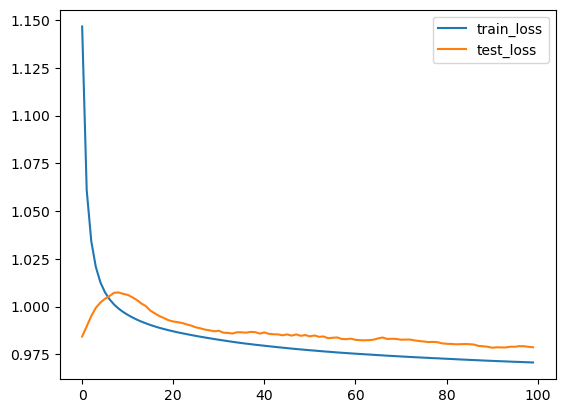

In [68]:
plt.plot(r.history['loss'], label = 'train_loss')
plt.plot(r.history['val_loss'], label = 'test_loss')
plt.legend();

In [69]:
''' overfitting clearly as observed in the 1 step as well'''

' overfitting clearly as observed in the 1 step as well'

In [70]:
Ptrain = model.predict(Xtrain_m)
Ptest = model.predict(Xtest_m)

70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


In [71]:
Ptrain.shape, Ptest.shape

((2231, 21), (1, 21))

In [72]:
Ptrain

array([[-0.09057696, -0.1302236 ,  0.34097317, ..., -0.03212209,
         0.01963191,  0.3303093 ],
       [ 0.00457486, -0.06969336,  0.06111107, ..., -0.07236838,
         0.01316077,  0.01138789],
       [-0.2895243 ,  0.10113716,  0.05753834, ...,  0.16024953,
         0.13674934,  0.07078409],
       ...,
       [ 0.12642649,  0.02462496, -0.04429428, ..., -0.04462856,
        -0.01822337, -0.01597809],
       [ 0.19909891,  0.08869968,  0.18300472, ..., -0.08925755,
        -0.14592795, -0.03352391],
       [ 0.02115286,  0.23927324,  0.02977043, ..., -0.23098376,
        -0.10767909,  0.12170529]], dtype=float32)

In [73]:
Ptrain = Ptrain[:,0] # keeping the closest predictions closer to current time since we believe it to be more accurate

In [74]:
# this is how the original Ptrain was - we just took the 1st column
# y1, y2, y3
# y2, y3, y4
# y3, y4, y5

In [75]:
Ptest

array([[ 0.0139171 ,  0.09858599, -0.03340334,  0.13839598,  0.02276348,
         0.12014878,  0.0915045 ,  0.11408876, -0.01037297,  0.08289047,
         0.12110509, -0.03997912,  0.08623399,  0.01789181, -0.04586582,
        -0.09890277,  0.08697691, -0.1857737 , -0.02097923,  0.10324106,
         0.0088544 ]], dtype=float32)

In [76]:
Ptest[0] # just grabbing the 0th row - no more rows since test has only 1 row of data

array([ 0.0139171 ,  0.09858599, -0.03340334,  0.13839598,  0.02276348,
        0.12014878,  0.0915045 ,  0.11408876, -0.01037297,  0.08289047,
        0.12110509, -0.03997912,  0.08623399,  0.01789181, -0.04586582,
       -0.09890277,  0.08697691, -0.1857737 , -0.02097923,  0.10324106,
        0.0088544 ], dtype=float32)

In [77]:
Ptest = Ptest[0]

In [78]:
Ptest = scaler.inverse_transform(Ptest.reshape(-1,1)).flatten()

In [79]:
df.loc[test_idx, 'multioutput'] = last_train + np.cumsum(Ptest)

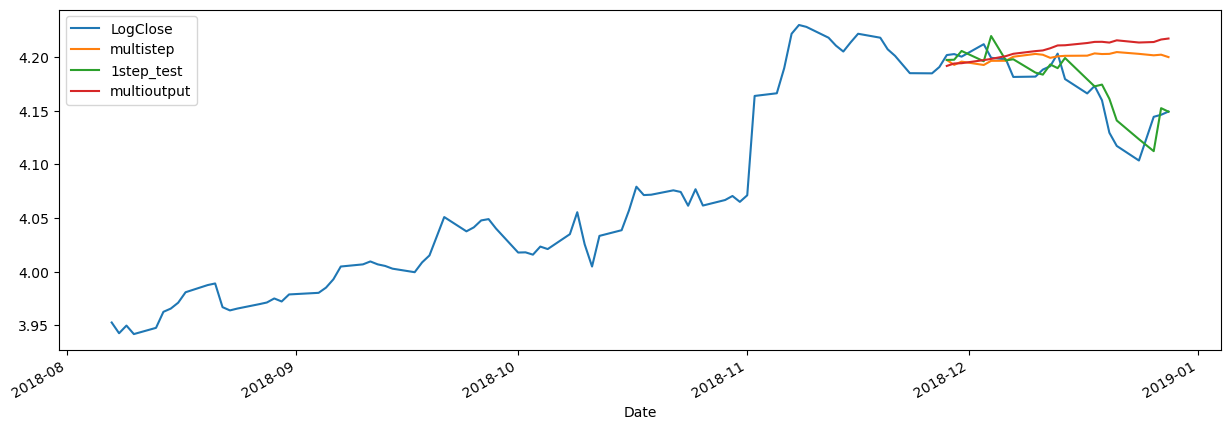

In [80]:
df.iloc[-100:][['LogClose','multistep','1step_test','multioutput']].plot(figsize =(15,5));

In [81]:
''' similar to the multioutput result'''

' similar to the multioutput result'

In [82]:
test_log_pass = df.iloc[-Ntest:]['LogClose']
mape1 =  mean_absolute_percentage_error(test_log_pass, df.loc[test_idx, 'multistep'])
mape2 =  mean_absolute_percentage_error(test_log_pass, df.loc[test_idx, 'multioutput'])
print("multistep MAPE:", mape1)
print("multioutput MAPE:", mape2)

multistep MAPE: 0.0076053298190902445
multioutput MAPE: 0.009259835165688948


In [83]:
'''the mapes are very small which indicates the results are pretty good, this is because the denominator is too large which is the actuals 
and the numerator which is the delta between actuals and predicted is very small'''

'''MAYBE CONSIDER A DIFFERENT METRIC SUCH AS R^2'''

'MAYBE CONSIDER A DIFFERENT METRIC SUCH AS R^2'

# 1-STEP binary classification

In [85]:
''' instead of predicting the price, checking if we can just predict the returns to be positive or negative'''

' instead of predicting the price, checking if we can just predict the returns to be positive or negative'

In [86]:
Ytrain_b = (Ytrain > 0) * 1 # multiplying by 1 to convert true false in to 0 and 1
Ytest_b = (Ytest > 0) * 1

In [87]:
Xtrain.shape

(2231, 10)

In [89]:
i = Input(shape = (T,))
x = Dense(32, activation ='relu')(i)
x = Dense(1)(x)
model = Model(i,x)

In [92]:
model.compile(
    loss = tf.keras.losses.BinaryCrossentropy(from_logits = True),
    optimizer ='adam',
    metrics  = ['accuracy'],
)

In [93]:
r = model.fit(
    Xtrain,
    Ytrain_b,
    epochs = 100,
    validation_data = (Xtest, Ytest_b),
)
    

Epoch 1/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.4872 - loss: 0.7244 - val_accuracy: 0.5714 - val_loss: 0.6607
Epoch 2/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5011 - loss: 0.7031 - val_accuracy: 0.5714 - val_loss: 0.6728
Epoch 3/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5016 - loss: 0.6967 - val_accuracy: 0.5238 - val_loss: 0.6788
Epoch 4/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5029 - loss: 0.6934 - val_accuracy: 0.5238 - val_loss: 0.6813
Epoch 5/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5052 - loss: 0.6912 - val_accuracy: 0.5238 - val_loss: 0.6815
Epoch 6/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.5074 - loss: 0.6896 - val_accuracy: 0.5238 - val_loss: 0.6803
Epoch 7/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5092 - loss: 0.6882 - val_accuracy: 0.5238 - val_loss: 0.6789
Epoch 8/100
70/70 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5092 - loss: 0.6870 - val_accuracy: 0.5238 - v

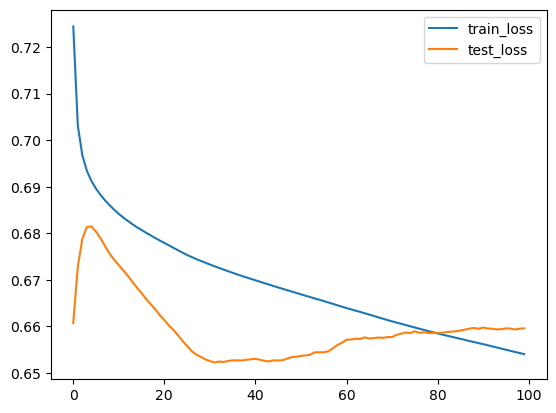

In [94]:
plt.plot(r.history['loss'], label = 'train_loss')
plt.plot(r.history['val_loss'], label = 'test_loss')
plt.legend();

In [96]:
''' this looks pretty good'''

' this looks pretty good'

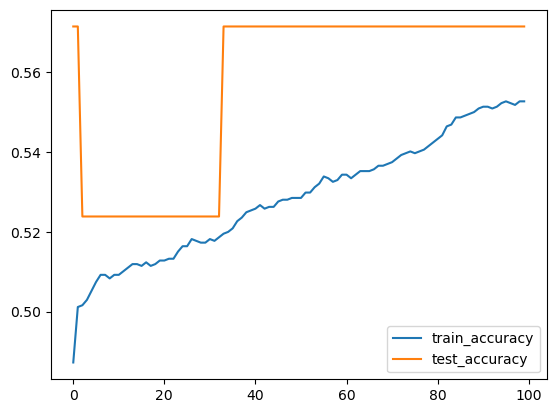

In [99]:
plt.plot(r.history['accuracy'], label = 'train_accuracy')
plt.plot(r.history['val_accuracy'], label = 'test_accuracy')
plt.legend();

In [100]:
''' for test, we are doing better than a coin toss'''

' for test, we are doing better than a coin toss'